# Analysis of the cosmology baseline $F$ problems

## Prelude

In [1]:
import pandas as pd
import seaborn as sns
import sympy

## Load data

In [2]:
report = pd.read_csv("Generated/full-report.csv")

In [3]:
report

,run_set,data_set,sample_num,rating,mse,expr_original_syms,expr
0,2026-06-16-2230,C1a,1,0.000019,6.745457e-11,((sqrt(z + 4.7668616246689375) - 1.0)*(2.14979...,((sqrt(x1 + 4.7668616246689375) - 1.0)*(2.1497...
1,2026-06-16-2230,C1a,2,0.000020,1.596802e-11,0.2508903032212249*z - 0.6570673776787787*sqrt...,0.2508903032212249*x1 - 0.6570673776787787*sqr...
2,2026-06-16-2230,C1a,3,0.000020,8.603853e-13,0.1790197841915341*z + 6.7954682163371533e-6*e...,0.1790197841915341*x1 + 6.7954682163371533e-6*...
3,2026-06-16-2230,C1a,4,0.000020,4.491967e-13,0.20523613919938938*z + 0.03535755736420625*as...,0.20523613919938938*x1 + 0.03535755736420625*a...
4,2026-06-16-2230,C1a,5,0.000018,5.882273e-11,((0.2670778722565918*sqrt(z) + 1.0)*(-1.955300...,((0.2670778722565918*sqrt(x1) + 1.0)*(-1.95530...
...,...,...,...,...,...,...,...
1147,2026-06-16-2230,F8,28,685062.763334,7.037302e+02,-0.0045595074549597351*x1**2*x2*x3 + 0.0181399...,-0.0045595074549597351*x1**2*x2*x3 + 0.0181399...
1148,2026-06-16-2230,F8,29,227568.734316,2.633933e+02,7.8753254458205573*x1*x2 + 5.997975096622334*x...,7.8753254458205573*x1*x2 + 5.997975096622334*x...
1149,2026-06-16-2230,F8,30,886904.821518,1.148850e+03,-0.001140795736715083*x1**2*x3**2*(x2 + 0.2203...,-0.001140795736715083*x1**2*x3**2*(x2 + 0.2203...
1150,2026-06-16-2230,F8,31,428126.156049,4.845284e+02,-0.004661350505146548*x1*x2*x3*(10.11075464055...,-0.004661350505146548*x1*x2*x3*(10.11075464055...


In [32]:
report["sympy_expr"] = report["expr_original_syms"].apply(lambda e: sympy.sympify(e))

In [35]:
report["sympy_expr_xs"] = report["expr"].apply(lambda e: sympy.sympify(e))

## Definitions

In [5]:
def get_data_set(data_set):
    return report[report["data_set"] == data_set]

In [6]:
def parse_if_needed(expr_or_str) -> sympy.Expr:
    if isinstance(expr_or_str, str):
        return sympy.sympify(expr_or_str)
    elif isinstance(expr_or_str, sympy.Expr):
        return expr_or_str
    else:
        raise ValueError("Input must be a string or a sympy expression")

In [7]:
def replace_near_integer(expr, tolerance=1e-5):
    if expr.func == sympy.Float:
        x = expr.evalf()
        x_int = round(x)
        x_frac = x - x_int
        if abs(x_frac) < tolerance:
            return sympy.Integer(x_int)
        else:
            return expr
    elif len(expr.args) == 0:
        return expr
    else:
        new_args = map(
            lambda e: replace_near_integer(e, tolerance=tolerance), expr.args
        )
        return expr.func(*new_args)

In [8]:
def to_spiffy(expr):
    expr = sympy.expand(expr, rational=False)
    expr = replace_near_integer(expr, tolerance=1e-6)
    # Too time consuming:
    # expr = sympy.simplify(expr)
    return expr

In [9]:
def generous_simplify(expr, tolerance=5e-3):
    expr = replace_near_integer(expr, tolerance=tolerance)
    expr = sympy.expand(expr, rational=False).evalf()
    expr = replace_near_integer(expr, tolerance=tolerance)
    expr = sympy.simplify(expr)
    expr = sympy.nsimplify(expr, tolerance=tolerance)
    return expr

In [10]:
def count_by_threshold(df, threshold):
    return sum(df["mse"] < threshold)

In [11]:
overall = {}

## Polynomials

Generally, the polynomial problems are easy.

### $F_1$

In [37]:
df_f1 = get_data_set("F1").sort_values("mse")

In [17]:
df_f1

,run_set,data_set,sample_num,rating,mse,expr_original_syms,expr,sympy_expr
924,2026-06-16-2230,F1,29,0.000052,4.636852e-22,feature*(1.0000000000000009*feature**4 - 2.000...,x1*(1.0000000000000009*x1**4 - 2.0000000000000...,x1*(1.0000000000000009*x1**4 - 2.0000000000000...
922,2026-06-16-2230,F1,27,0.000054,5.534444e-22,(feature*(feature + 0.025)*(0.9999999999999988...,(x1*(x1 + 0.025)*(0.9999999999999988*x1*(x1**2...,(x1*(x1 + 0.025)*(0.9999999999999988*x1*(x1**2...
926,2026-06-16-2230,F1,31,0.000045,1.606727e-21,0.9999999999999902*feature**5 - 1.999999999998...,0.9999999999999902*x1**5 - 1.9999999999988385*...,0.9999999999999902*x1**5 - 1.9999999999988385*...
920,2026-06-16-2230,F1,25,0.000032,2.109021e-21,1.000000000000011*feature**5 - 2.0000000000011...,1.000000000000011*x1**5 - 2.0000000000011903*x...,1.000000000000011*x1**5 - 2.0000000000011903*x...
914,2026-06-16-2230,F1,19,0.000048,7.244750e-21,1.0000000000000198*feature**5 + 1.866703123622...,1.0000000000000198*x1**5 + 1.8667031236222055e...,1.0000000000000198*x1**5 + 1.8667031236222055e...
904,2026-06-16-2230,F1,9,0.000048,1.276139e-20,feature*(1.0000000000000069*feature**4 + 1.533...,x1*(1.0000000000000069*x1**4 + 1.5330439088286...,x1*(1.0000000000000069*x1**4 + 1.5330439088286...
918,2026-06-16-2230,F1,23,0.000055,2.962737e-20,1.0000000000000369*feature**5 - 9.876092980758...,1.0000000000000369*x1**5 - 9.8760929807587841e...,1.0000000000000369*x1**5 - 9.8760929807587841e...
901,2026-06-16-2230,F1,6,0.000045,5.077890e-20,feature*(1.000000000000053*feature**4 - 2.0000...,x1*(1.000000000000053*x1**4 - 2.00000000000610...,x1*(1.000000000000053*x1**4 - 2.00000000000610...
909,2026-06-16-2230,F1,14,0.000045,5.695479e-20,1.0000000000000542*feature**5 - 5.687117443642...,1.0000000000000542*x1**5 - 5.6871174436423644e...,1.0000000000000542*x1**5 - 5.6871174436423644e...
905,2026-06-16-2230,F1,10,0.000042,5.805202e-20,feature*(0.9999999999999397*feature**4 - 1.999...,x1*(0.9999999999999397*x1**4 - 1.9999999999929...,x1*(0.9999999999999397*x1**4 - 1.9999999999929...


In [38]:
df_f1["sympy_expr_xs"].apply(generous_simplify)

924    x1**5 - 2*x1**3 + x1
922    x1**5 - 2*x1**3 + x1
926    x1**5 - 2*x1**3 + x1
920    x1**5 - 2*x1**3 + x1
914    x1**5 - 2*x1**3 + x1
904    x1**5 - 2*x1**3 + x1
918    x1**5 - 2*x1**3 + x1
901    x1**5 - 2*x1**3 + x1
909    x1**5 - 2*x1**3 + x1
905    x1**5 - 2*x1**3 + x1
927    x1**5 - 2*x1**3 + x1
925    x1**5 - 2*x1**3 + x1
911    x1**5 - 2*x1**3 + x1
906    x1**5 - 2*x1**3 + x1
908    x1**5 - 2*x1**3 + x1
917    x1**5 - 2*x1**3 + x1
915    x1**5 - 2*x1**3 + x1
900    x1**5 - 2*x1**3 + x1
912    x1**5 - 2*x1**3 + x1
907    x1**5 - 2*x1**3 + x1
921    x1**5 - 2*x1**3 + x1
910    x1**5 - 2*x1**3 + x1
919    x1**5 - 2*x1**3 + x1
916    x1**5 - 2*x1**3 + x1
913    x1**5 - 2*x1**3 + x1
902    x1**5 - 2*x1**3 + x1
898    x1**5 - 2*x1**3 + x1
896    x1**5 - 2*x1**3 + x1
923    x1**5 - 2*x1**3 + x1
899    x1**5 - 2*x1**3 + x1
903    x1**5 - 2*x1**3 + x1
897    x1**5 - 2*x1**3 + x1
Name: sympy_expr_xs, dtype: object

After rounding, all of these are correct apart from debris.

In [20]:
mse_threshold = 1e-11
ballpark_threshold = 5e-3

overall["F1"] = {
    "data_set": "F1",
    "perfect": 32,
    "mse_threshold": mse_threshold,
    "numerically_close": count_by_threshold(df_f1, mse_threshold),
    "ballpark_threshold": ballpark_threshold,
    "ballpark": count_by_threshold(df_f1, ballpark_threshold),
}

### $F_4$

In [39]:
df_f4 = get_data_set("F4").sort_values("mse")

In [40]:
df_f4["sympy_expr"].apply(generous_simplify)

997     5*x1**4/2 - 13*x1**3/10 + x2**2/2 - 17*x2/10
1013    5*x1**4/2 - 13*x1**3/10 + x2**2/2 - 17*x2/10
1002    5*x1**4/2 - 13*x1**3/10 + x2**2/2 - 17*x2/10
1011    5*x1**4/2 - 13*x1**3/10 + x2**2/2 - 17*x2/10
992     5*x1**4/2 - 13*x1**3/10 + x2**2/2 - 17*x2/10
1009    5*x1**4/2 - 13*x1**3/10 + x2**2/2 - 17*x2/10
1023    5*x1**4/2 - 13*x1**3/10 + x2**2/2 - 17*x2/10
1018    5*x1**4/2 - 13*x1**3/10 + x2**2/2 - 17*x2/10
994     5*x1**4/2 - 13*x1**3/10 + x2**2/2 - 17*x2/10
1005    5*x1**4/2 - 13*x1**3/10 + x2**2/2 - 17*x2/10
1007    5*x1**4/2 - 13*x1**3/10 + x2**2/2 - 17*x2/10
1016    5*x1**4/2 - 13*x1**3/10 + x2**2/2 - 17*x2/10
1001    5*x1**4/2 - 13*x1**3/10 + x2**2/2 - 17*x2/10
995     5*x1**4/2 - 13*x1**3/10 + x2**2/2 - 17*x2/10
1014    5*x1**4/2 - 13*x1**3/10 + x2**2/2 - 17*x2/10
1006    5*x1**4/2 - 13*x1**3/10 + x2**2/2 - 17*x2/10
1017    5*x1**4/2 - 13*x1**3/10 + x2**2/2 - 17*x2/10
1003    5*x1**4/2 - 13*x1**3/10 + x2**2/2 - 17*x2/10
996     5*x1**4/2 - 13*x1**3/10 + x2**2/2 - 17

After rounding, all of these are correct.

In [23]:
mse_threshold = 1e-11
ballpark_threshold = 5e-3

overall["F4"] = {
    "data_set": "F4",
    "perfect": 32,
    "mse_threshold": mse_threshold,
    "numerically_close": count_by_threshold(df_f4, mse_threshold),
    "ballpark_threshold": ballpark_threshold,
    "ballpark": count_by_threshold(df_f4, ballpark_threshold),
}

## Rational functions

### $F_7$

In [41]:
df_f7 = get_data_set("F7").sort_values("mse")

<Axes: xlabel='mse', ylabel='Count'>

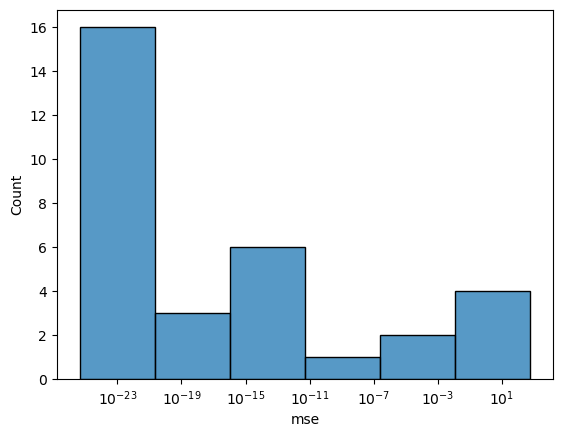

In [42]:
sns.histplot(df_f7["mse"], log_scale=True)

In [43]:
df_f7["sympy_expr"].apply(lambda e: generous_simplify(e, tolerance=5e-4))

1110                 (71*x1/15 + 71*x2/15 + 23*x3/100)/x3
1106                 (71*x1/15 + 71*x2/15 + 23*x3/100)/x3
1111                 (71*x1/15 + 71*x2/15 + 23*x3/100)/x3
1118                 (71*x1/15 + 71*x2/15 + 23*x3/100)/x3
1088                 (71*x1/15 + 71*x2/15 + 23*x3/100)/x3
1104                 (71*x1/15 + 71*x2/15 + 23*x3/100)/x3
1117    (71*x1**2/15 + 71*x1*x2/15 + 23*x1*x3/100 - 16...
1112                 (71*x1/15 + 71*x2/15 + 23*x3/100)/x3
1116                 (71*x1/15 + 71*x2/15 + 23*x3/100)/x3
1100                 (71*x1/15 + 71*x2/15 + 23*x3/100)/x3
1096                 (71*x1/15 + 71*x2/15 + 23*x3/100)/x3
1097                 (71*x1/15 + 71*x2/15 + 23*x3/100)/x3
1099                 (71*x1/15 + 71*x2/15 + 23*x3/100)/x3
1093    (-71*x1**2/15 - 23*x1*x3/100 + 71*x1/15 + 71*x...
1094                 (71*x1/15 + 71*x2/15 + 23*x3/100)/x3
1098                 (71*x1/15 + 71*x2/15 + 23*x3/100)/x3
1108    (71*x1*x3/15 + 71*x1/600 + 71*x2*x3/15 + 71*x2...
1090          

There are 21 clearly good.

In [49]:
mse_threshold = 1e-11
ballpark_threshold = 5e-3
overall["F7"] = {
    "data_set": "F7",
    "perfect": 17,
    "mse_threshold": mse_threshold,
    "numerically_close": count_by_threshold(df_f7, mse_threshold),
    "ballpark_threshold": ballpark_threshold,
    "ballpark": count_by_threshold(df_f7, ballpark_threshold),
}

## Medium

### $F_5$

In [44]:
df_f5 = get_data_set("F5").sort_values("mse")

<Axes: xlabel='mse', ylabel='Count'>

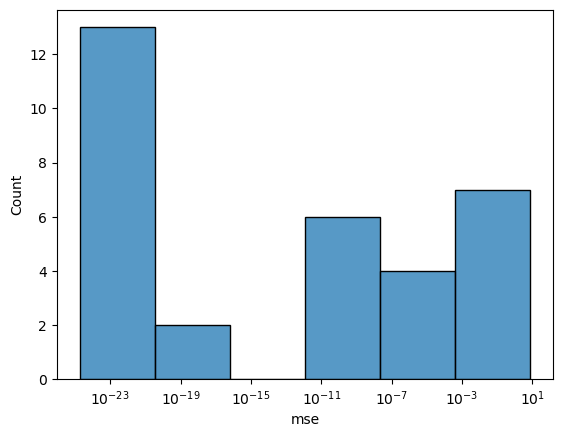

In [45]:
sns.histplot(df_f5["mse"], log_scale=True)

In [47]:
df_f5["sympy_expr"].apply(
    lambda e: generous_simplify(e, tolerance=5e-2)
)

1050                              3*exp(x1)/2 + 5*cos(x2)
1026                              3*exp(x1)/2 + 5*cos(x2)
1043                              3*exp(x1)/2 + 5*cos(x2)
1040                              3*exp(x1)/2 + 5*cos(x2)
1046                              3*exp(x1)/2 + 5*cos(x2)
1028                              3*exp(x1)/2 + 5*cos(x2)
1053                              3*exp(x1)/2 + 5*cos(x2)
1048                              3*exp(x1)/2 + 5*cos(x2)
1035                              3*exp(x1)/2 + 5*cos(x2)
1027                              3*exp(x1)/2 + 5*cos(x2)
1030                              3*exp(x1)/2 + 5*cos(x2)
1036                              3*exp(x1)/2 + 5*cos(x2)
1039                              3*exp(x1)/2 + 5*cos(x2)
1025                              3*exp(x1)/2 + 5*cos(x2)
1045                              3*exp(x1)/2 + 5*cos(x2)
1041                              3*exp(x1)/2 + 5*cos(x2)
1032                3*exp(x1)/2 + 5*sin(x2 + 11/7) + 2/17
1034          

There are 20 good ones.
A couple have  $\sin(x + \pi/2(1+\epsilon))$ instead of $\cos(x)$.

In [51]:
mse_threshold = 1e-11
ballpark_threshold = 5e-3
overall["F5"] = {
    "data_set": "F5",
    "perfect": 20,
    "mse_threshold": mse_threshold,
    "numerically_close": count_by_threshold(df_f5, mse_threshold),
    "ballpark_threshold": ballpark_threshold,
    "ballpark": count_by_threshold(df_f5, ballpark_threshold),
}

## Overall

In [52]:
pd.DataFrame(overall).T

,data_set,perfect,mse_threshold,numerically_close,ballpark_threshold,ballpark
F1,F1,32,0.0,28,0.005,32
F2,F2,32,0.0,0,0.005,1
F4,F4,32,0.0,32,0.005,32
F7,F7,17,0.0,25,0.005,26
F5,F5,20,0.0,21,0.005,25
